In [ ]:
# authors
# Nguyen Van Hoang Khang

In [ ]:
# warning:
# only customize the 3-4-5 blocks

In [2]:
# library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# input your data here
from pathlib import Path

COL_pv = ['date', 'opn', 'cls', 'low', 'high', 'nsh', 'vol', 'adj']

base_dir = Path.cwd()
home = str(base_dir)  # keep this name for helper cells below

stk = 's1'  # change to s2..s30 for quick experiments

default_path = base_dir / 'sample_data' / f"{stk}.npy"
legacy_path = base_dir / 'data' / 'pv' / f"{stk}.npy"
A = np.load(legacy_path if legacy_path.exists() else default_path, allow_pickle=True)

P = A[:, 2].astype(float)
V = A[:, 6].astype(float)


In [5]:
# customize your prediction
def prediction(P, V, h=20):
    def clip_ret(x):
        if x < -0.07:
            return -0.07
        if x > 0.07:
            return 0.07
        return x

    P = np.asarray(P, dtype=float)
    V = np.asarray(V, dtype=float)
    n = len(P)

    if n == 0:
        return []

    eps = 1e-12
    r = np.zeros(n)
    r[1:] = P[1:] / np.maximum(P[:-1], eps) - 1.0

    x = np.zeros((n, 5), dtype=float)
    for i in range(n):
        j5 = max(0, i - 5)
        j20 = max(0, i - h)

        ma5 = np.mean(P[j5 : i + 1])
        ma20 = np.mean(P[j20 : i + 1])
        vma20 = np.mean(V[j20 : i + 1])

        x[i, 0] = r[i]
        x[i, 1] = P[i] / np.maximum(ma5, eps) - 1.0
        x[i, 2] = P[i] / np.maximum(ma20, eps) - 1.0
        x[i, 3] = np.log(np.maximum(V[i], eps) / np.maximum(vma20, eps))
        x[i, 4] = r[i] * x[i, 3]

    # Build online ridge model: features at day i predict return at day i+1
    pred = np.zeros(n)
    warmup = max(30, h + 5)
    lam = 1e-2

    for i in range(n):
        if i < warmup:
            pred[i] = 0.5 * x[i, 0] - 0.5 * x[i, 2]
            continue

        Xtr = x[:i]
        ytr = r[1 : i + 1]

        X_design = np.hstack([np.ones((len(Xtr), 1)), Xtr])
        I = np.eye(X_design.shape[1])
        I[0, 0] = 0.0

        beta = np.linalg.solve(X_design.T @ X_design + lam * I, X_design.T @ ytr)
        xf = np.concatenate([[1.0], x[i]])
        pred[i] = float(xf @ beta)

    return [clip_ret(v) for v in pred]


In [ ]:
# keep the core function unchanged
def target(P, V):
    n, Q = len(P), [0]
    for i in range(1, n):
        Q.append(P[i] / P[i -1] - 1)
    return Q

def evaluate(p, t, dspl=False):
    p, t = p[1 :], t[1 :]
    n, e, f = len(t), [], []
    for i in range(1, n):
        e.append(t[i] - p[i - 1])
        f.append(t[i])
    den = np.nanquantile(np.abs(e), 0.5) + 0.5 * np.nanquantile(np.abs(e), 0.9)
    num = np.nanquantile(np.abs(f), 0.5) + 0.5 * np.nanquantile(np.abs(f), 0.9)
    if dspl == True:
        print(f"\n\tbase = {round(num, 3)}  |  abs = {round(den, 3)}  |  rel = {round(1 - den / num, 3)}\n")
        plt.hist(e, edgecolor='black')
        plt.show()
    else:
        return den, 1 - den / num


	base = 0.011  |  abs = 0.012  |  rel = -0.049



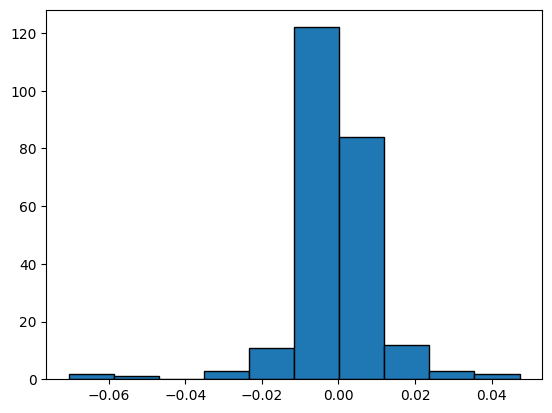

In [ ]:
# execute
# Note that score "rel" > 0 shows that there are good signals, "abs" < 0.005 is good signal
p, t = prediction(P, V, 5), target(P, V)
evaluate(p, t, True)

In [ ]:
def load_PV(stk, dint=[20240101, 20250101]):
    A = np.load(f"{home}/data/pv/{stk}.npy", allow_pickle=True)
    A = A[(A[:, 0] >= dint[0]) & (A[:, 0] < dint[1])]
    return A[:, 2], A[:, 6]

def get_ma(P, h=20):
    M, n = [], len(P)
    for i in range(n):
        tmp = i - h if i >= h else 0
        M.append(np.nanmean(P[tmp : i + 1]))
    return np.array(M)

def get_grw(P):
    return P / P[0] - 1

def get_acc(C, h=5):
    A, n = [], len(C)
    for i in range(n):
        tmp = i - h if i >= h else 0
        A.append(C[i] / C[tmp] - 1)
    return np.array(A)

In [ ]:
stk = 'FPT'
P, V = load_PV(stk)
G = get_grw(P)
ma = get_ma(G)
diff = G - ma
acc = get_acc(ma)

plt.plot(np.arange(len(ma)), ma)
plt.plot(np.arange(len(diff)), diff)
plt.plot(np.arange(len(G)), G)
#plt.plot(np.arange(len(acc)), acc)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'd:\\InterviewAssignment\\HelpKhang\\20252_CO5115_CH01/data/pv/FPT.npy'

0.5809275054564906


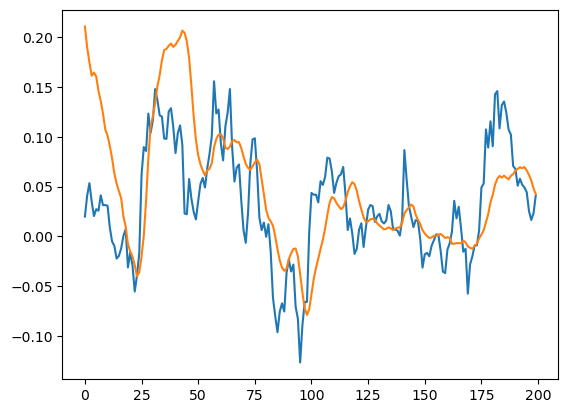

In [ ]:
X, Y = diff[50 :], acc[50 :]
print(np.corrcoef(X, Y)[0, 1])

plt.plot(np.arange(len(X)), X)
plt.plot(np.arange(len(Y)), Y)
plt.show()

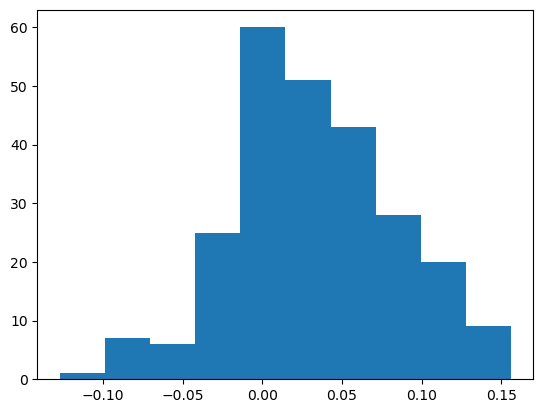

In [ ]:
plt.hist(diff)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_11824\3463677529.py:6: RuntimeWarning: invalid value encountered in power
  W = W**(0.25)
C:\Users\DELL\AppData\Local\Temp\ipykernel_11824\3463677529.py:8: RuntimeWarning: divide by zero encountered in divide
  rat = W / G
C:\Users\DELL\AppData\Local\Temp\ipykernel_11824\3463677529.py:8: RuntimeWarning: invalid value encountered in divide
  rat = W / G


0.7520234168202738


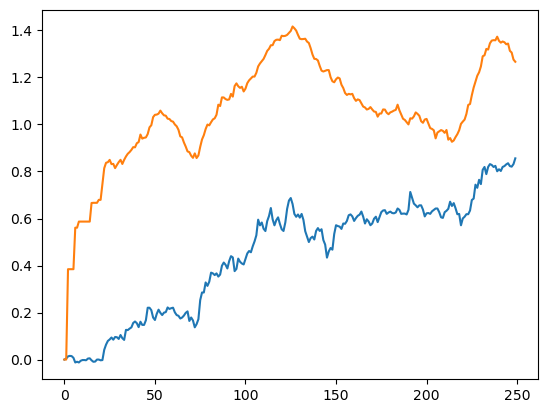

In [ ]:
stk = 'FPT'
P, V = load_PV(stk)

G = get_grw(P)
W = get_grw(V)
W = W**(0.25)
W = get_ma(W, 20)
rat = W / G

print(np.corrcoef(G, W)[0, 1])
plt.plot(np.arange(len(G)), G)
plt.plot(np.arange(len(W)), W)
#plt.plot(np.arange(len(rat)), rat)
plt.show()

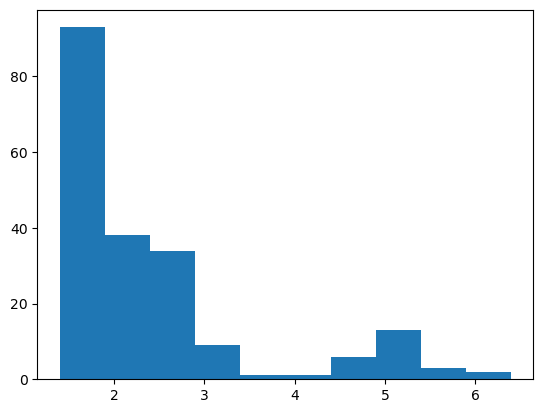

In [ ]:
plt.hist(rat[50 :])
plt.show()